**Exploratory Data Analysis on Chilli Plant Disease Dataset**

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Updated Correct Paths
path1 = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Leaf Disease Original Dataset'
path2 = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Growth Stage Original Dataset'

def load_data_info(root_path):
    data = []
    if not os.path.exists(root_path):
        print(f"⚠️ Warning: {root_path} not found.")
        return pd.DataFrame()
    for category in sorted(os.listdir(root_path)):
        cat_path = os.path.join(root_path, category)
        if os.path.isdir(cat_path):
            images = [f for f in os.listdir(cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            for img in images:
                data.append({'Class': category, 'Path': os.path.join(cat_path, img)})
    return pd.DataFrame(data)

df_disease = load_data_info(path1)
df_growth = load_data_info(path2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded 1856 images from Chili Leaf Disease Original Dataset
✅ Loaded 1714 images from Chili Growth Stage Original Dataset


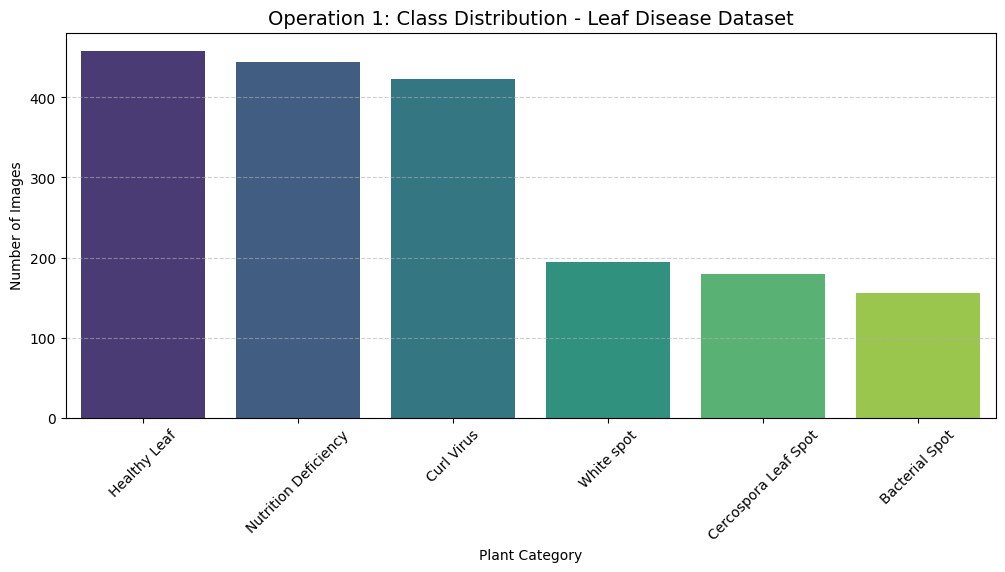

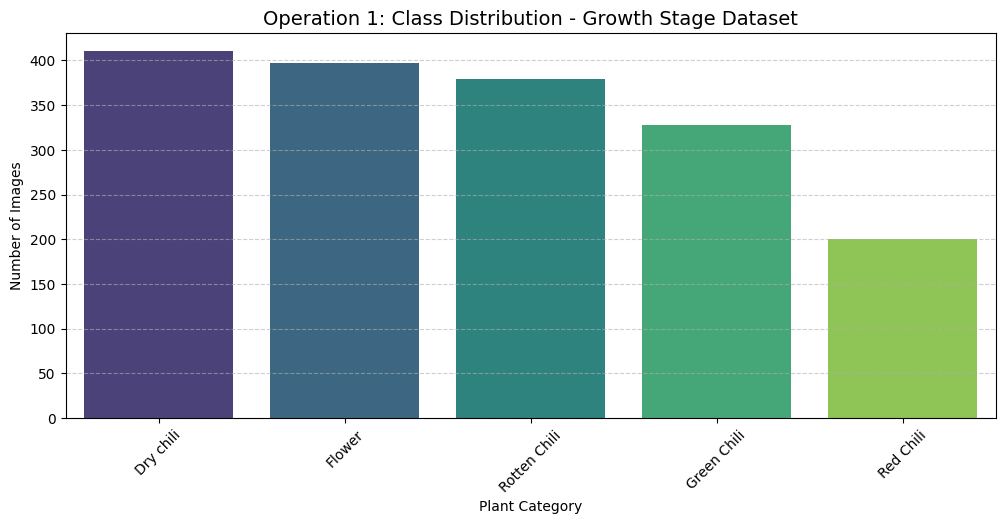

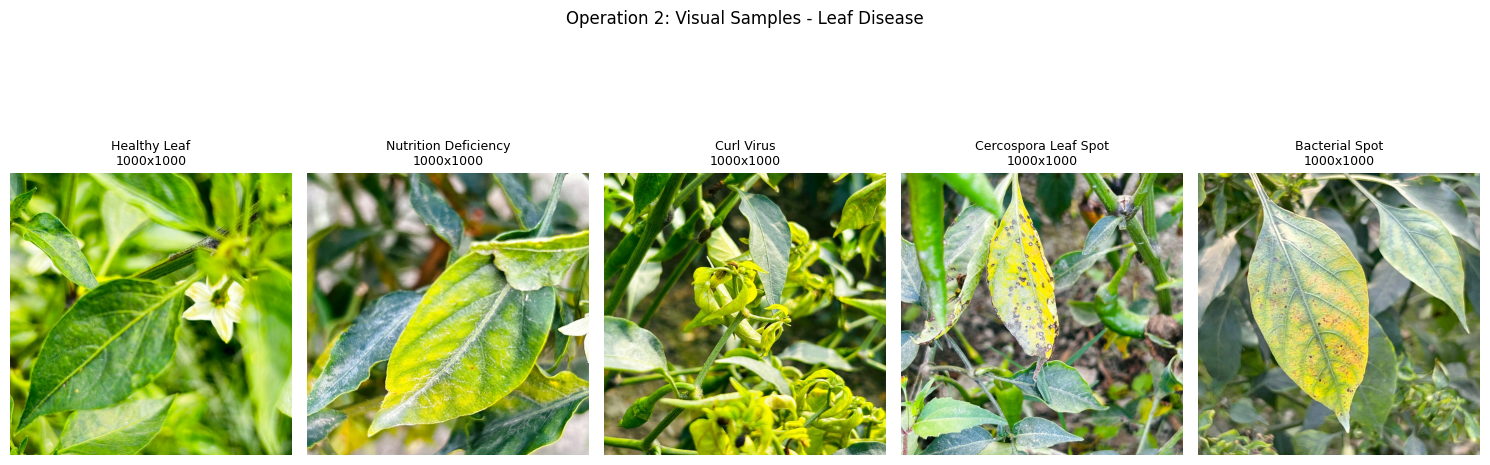

In [26]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define Final Correct Paths
path1 = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Leaf Disease Original Dataset'
path2 = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Growth Stage Original Dataset'

def load_data_robust(root_path):
    data = []
    if not os.path.exists(root_path):
        print(f"❌ Directory not found: {root_path}")
        return pd.DataFrame()

    # Get subfolders (classes)
    categories = [d for d in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, d))]

    for cat in categories:
        cat_path = os.path.join(root_path, cat)
        images = [f for f in os.listdir(cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for img in images:
            # Explicitly naming the column 'Class' to match your plot function
            data.append({'Class': cat, 'Path': os.path.join(cat_path, img)})

    df = pd.DataFrame(data)
    if df.empty:
        print(f"⚠️ No images found in: {root_path}")
    else:
        print(f"✅ Loaded {len(df)} images from {os.path.basename(root_path)}")
    return df

# Load the data
df_disease = load_data_robust(path1)
df_growth = load_data_robust(path2)

# --- EDA OPERATION 1: CLASS DISTRIBUTION ---
def plot_distribution(df, title):
    if df.empty:
        print(f"Skipping plot for {title}: DataFrame is empty.")
        return

    plt.figure(figsize=(12, 5))
    # Count occurrences of each class
    counts = df['Class'].value_counts()

    sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='viridis', legend=False)

    plt.title(f'Operation 1: Class Distribution - {title}', fontsize=14)
    plt.xticks(rotation=45)
    plt.xlabel('Plant Category')
    plt.ylabel('Number of Images')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

# Run the plots
plot_distribution(df_disease, "Leaf Disease Dataset")
plot_distribution(df_growth, "Growth Stage Dataset")

# --- EDA OPERATION 2: IMAGE SAMPLES ---
def plot_samples(df, title):
    if df.empty: return
    classes = df['Class'].unique()
    plt.figure(figsize=(15, 6))
    for i, cls in enumerate(classes[:5]): # Show first 5 classes
        sample_path = df[df['Class'] == cls]['Path'].iloc[0]
        img = cv2.imread(sample_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.title(f"{cls}\n{img.shape[1]}x{img.shape[0]}", fontsize=9)
        plt.axis('off')
    plt.suptitle(f"Operation 2: Visual Samples - {title}")
    plt.tight_layout()
    plt.show()

plot_samples(df_disease, "Leaf Disease")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded 1856 images from Chili Leaf Disease Original Dataset
✅ Loaded 1714 images from Chili Growth Stage Original Dataset


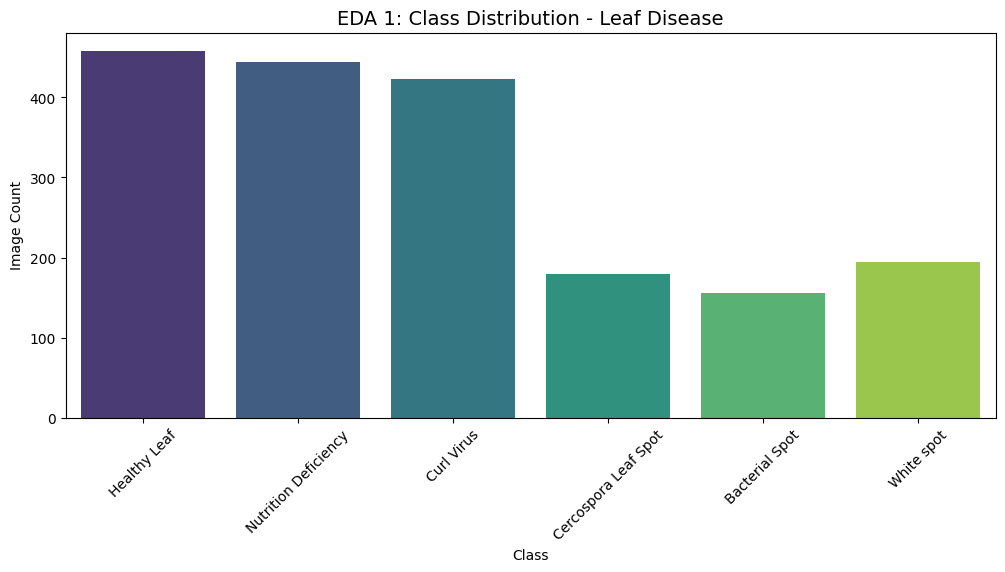

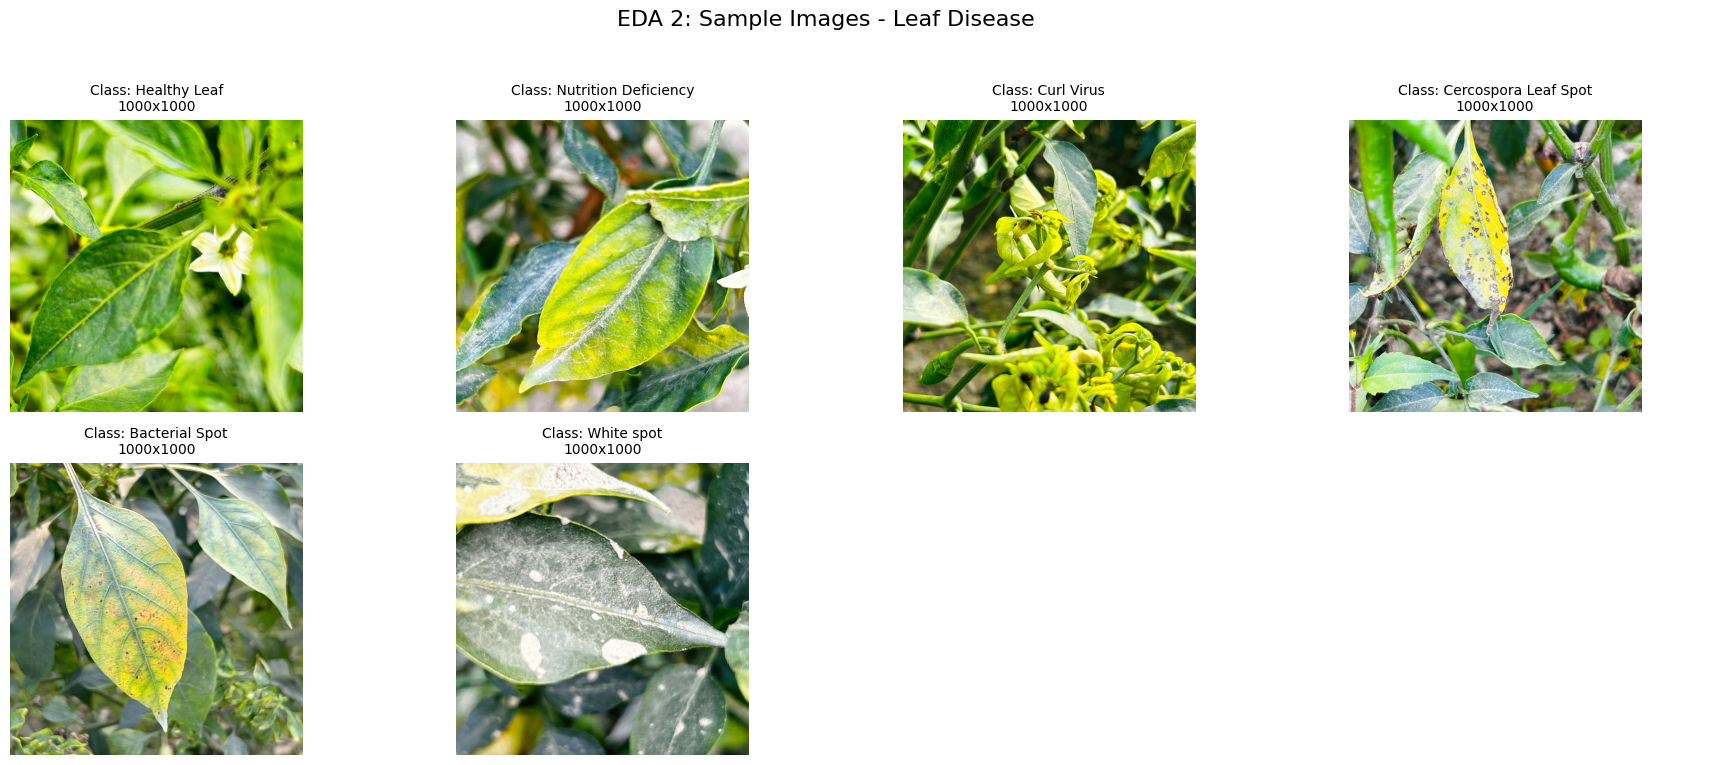

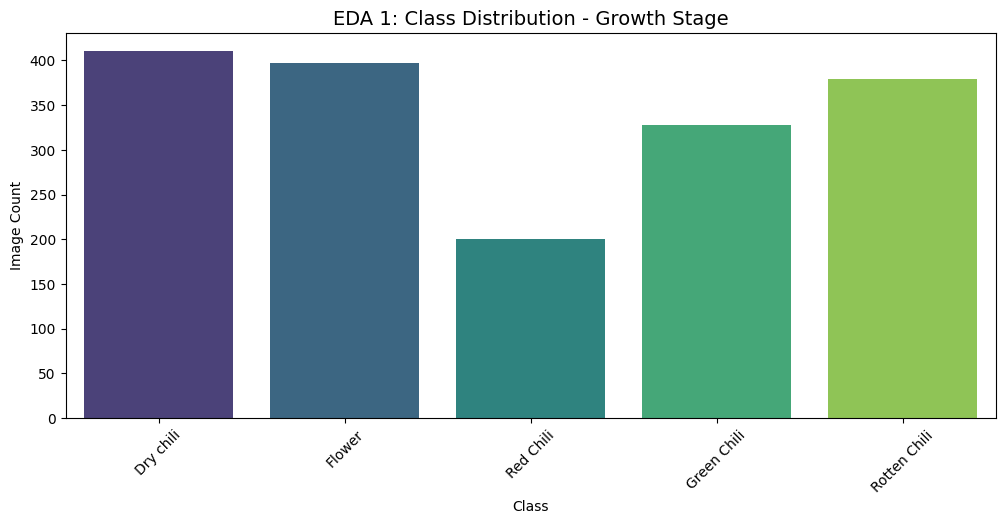

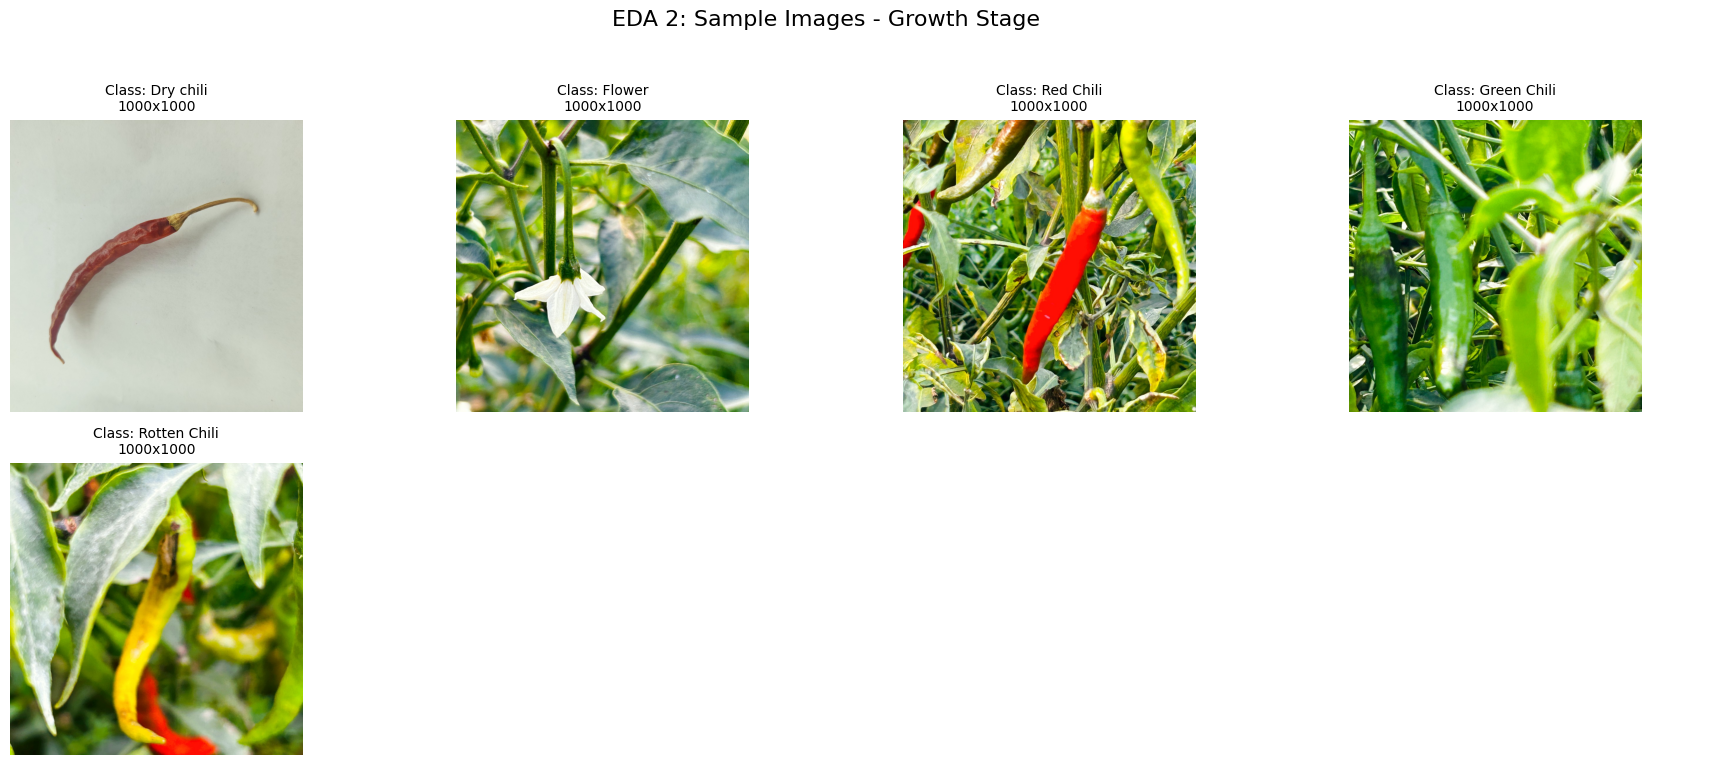

In [27]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Setup Exact Paths
path_disease = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Leaf Disease Original Dataset'
path_growth = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Growth Stage Original Dataset'

def load_chili_data(root_path):
    data = []
    if not os.path.exists(root_path):
        print(f"❌ Path not found: {root_path}")
        return pd.DataFrame()

    # Get subfolders
    folders = [f for f in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, f))]

    for folder in folders:
        folder_path = os.path.join(root_path, folder)
        images = [img for img in os.listdir(folder_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for img_name in images:
            # We FORCE the column name to be 'Class' here
            data.append({
                'Class': folder,
                'Path': os.path.join(folder_path, img_name)
            })

    df = pd.DataFrame(data)
    if df.empty:
        print(f"⚠️ No images found in {root_path}")
    else:
        print(f"✅ Loaded {len(df)} images from {os.path.basename(root_path)}")
    return df

# Create DataFrames
df_disease = load_chili_data(path_disease)
df_growth = load_chili_data(path_growth)

# --- EDA OPERATION 1: Class Distribution ---
def plot_distribution(df, title):
    if 'Class' not in df.columns or df.empty:
        print(f"Skipping Distribution for {title}: Data missing.")
        return

    plt.figure(figsize=(12, 5))
    # Using value_counts() ensures we have data to plot
    sns.countplot(data=df, x='Class', hue='Class', palette='viridis', legend=False)
    plt.title(f'EDA 1: Class Distribution - {title}', fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel('Image Count')
    plt.show()

# --- EDA OPERATION 2: Visual Grid ---
def show_visual_grid(df, title):
    if 'Class' not in df.columns or df.empty:
        print(f"Skipping Visual Grid for {title}: Data missing.")
        return

    classes = df['Class'].unique()
    num_classes = len(classes)
    cols = 4
    rows = int(np.ceil(num_classes / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
    axes = axes.flatten()

    for i, cls in enumerate(classes):
        img_info = df[df['Class'] == cls].iloc[0]
        img = cv2.imread(img_info['Path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img)
        axes[i].set_title(f"Class: {cls}\n{img.shape[1]}x{img.shape[0]}", fontsize=10)
        axes[i].axis('off')

    # Clean up empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"EDA 2: Sample Images - {title}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Execute Operations
plot_distribution(df_disease, "Leaf Disease")
show_visual_grid(df_disease, "Leaf Disease")

plot_distribution(df_growth, "Growth Stage")
show_visual_grid(df_growth, "Growth Stage")

Mounted at /content/drive
✅ Success! Loaded 1856 images across 6 classes.
Classes found: ['Bacterial Spot' 'Cercospora Leaf Spot' 'Curl Virus' 'Healthy Leaf'
 'Nutrition Deficiency' 'White spot']


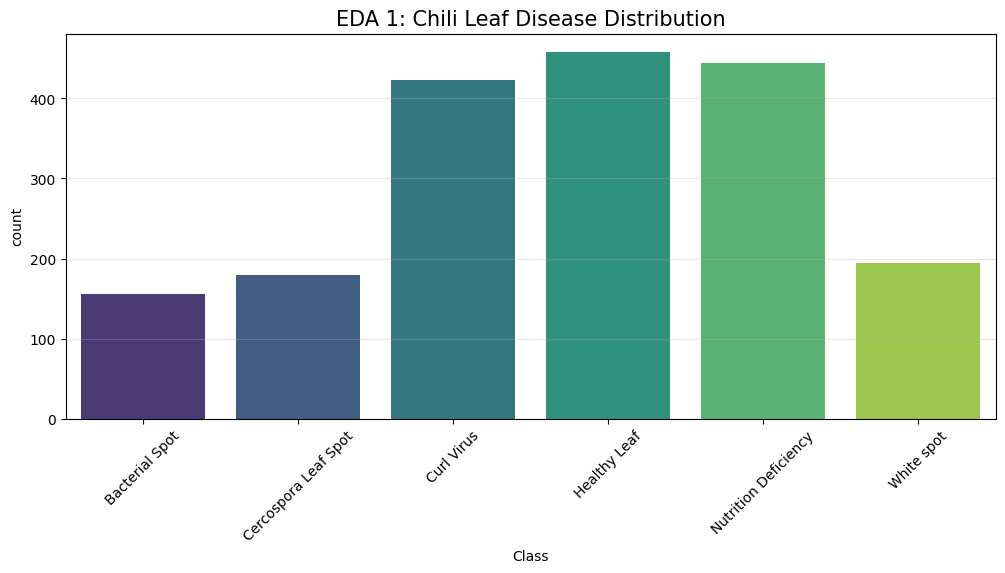

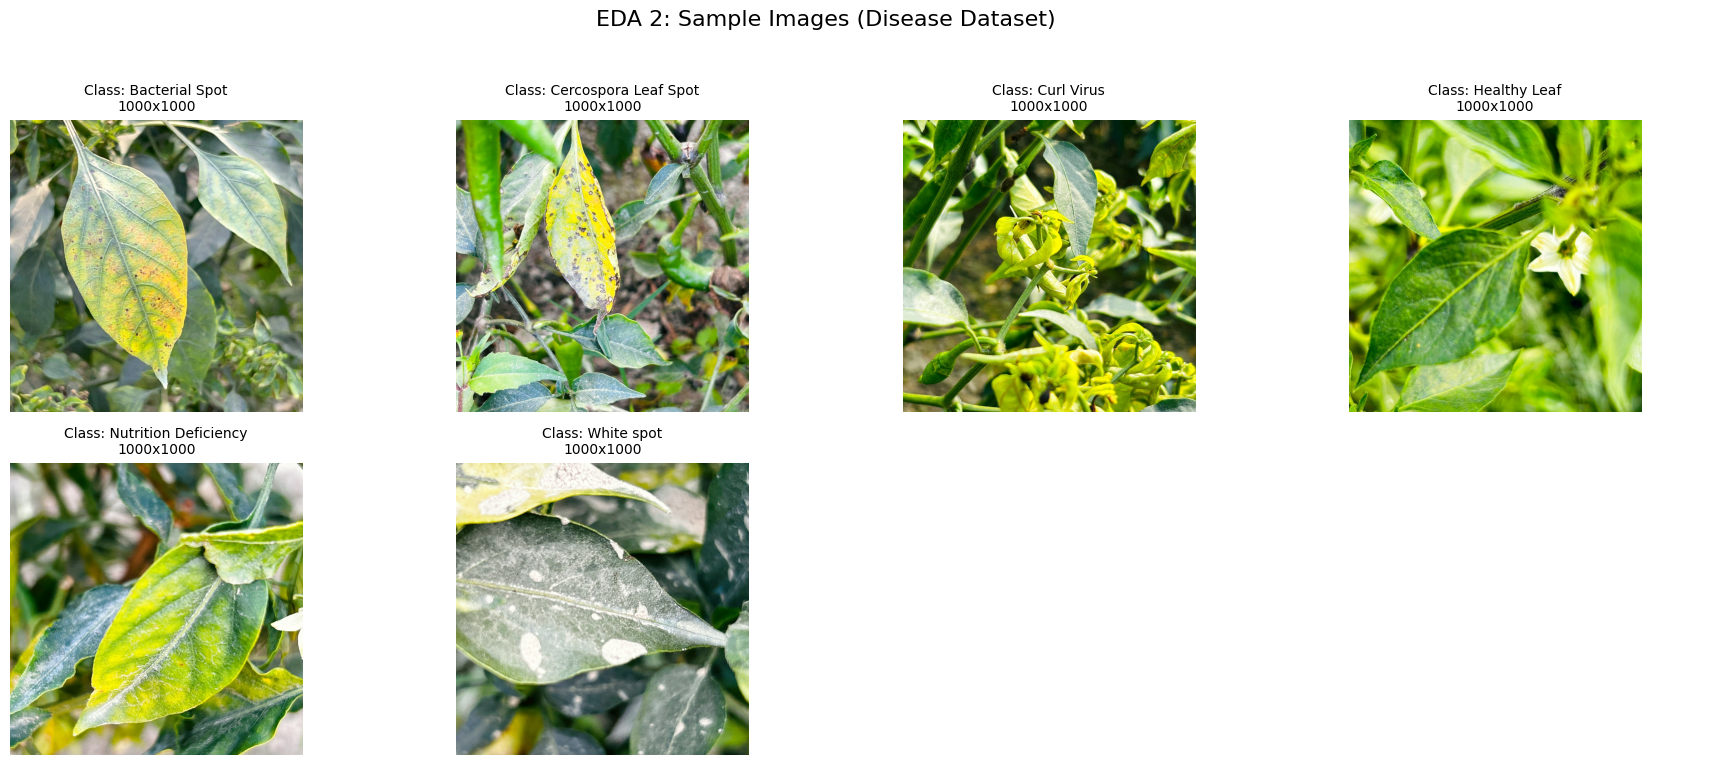

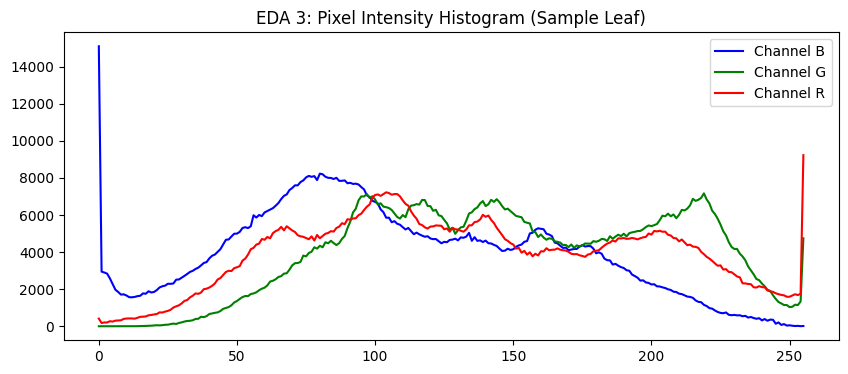

In [28]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive', force_remount=True)

# 2. Setup Exact Paths
disease_path = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Leaf Disease Original Dataset'

def load_and_fix_disease_data(root):
    data_list = []
    if not os.path.exists(root):
        print(f"❌ ERROR: Path not found at {root}")
        return pd.DataFrame()

    # Get only valid directories (the disease classes)
    classes = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]

    for cls in sorted(classes):
        cls_path = os.path.join(root, cls)
        # Get all image files
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for img_name in images:
            data_list.append({
                'Class': str(cls), # Force column name 'Class'
                'Path': os.path.join(cls_path, img_name)
            })

    # Create DataFrame and explicitly define columns to avoid KeyError
    df = pd.DataFrame(data_list, columns=['Class', 'Path'])

    if df.empty:
        print("⚠️ Warning: No images found. Check if the subfolders contain .jpg or .png files.")
    else:
        print(f"✅ Success! Loaded {len(df)} images across {df['Class'].nunique()} classes.")
        print(f"Classes found: {df['Class'].unique()}")

    return df

# Load the Disease Dataset
df_disease = load_and_fix_disease_data(disease_path)

# --- EDA OPERATION 1: Class Distribution ---
if not df_disease.empty:
    plt.figure(figsize=(12, 5))
    # Direct plot using the forced 'Class' column
    sns.countplot(data=df_disease, x='Class', hue='Class', palette='viridis', legend=False)
    plt.title('EDA 1: Chili Leaf Disease Distribution', fontsize=15)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # --- EDA OPERATION 2: Visual Grid ---
    classes = df_disease['Class'].unique()
    rows = int(np.ceil(len(classes) / 4))
    fig, axes = plt.subplots(rows, 4, figsize=(18, rows * 4))
    axes = axes.flatten()

    for i, cls in enumerate(classes):
        # Get the first image path for this class
        sample_path = df_disease[df_disease['Class'] == cls]['Path'].iloc[0]
        img = cv2.imread(sample_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img)
        axes[i].set_title(f"Class: {cls}\n{img.shape[1]}x{img.shape[0]}", fontsize=10)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle("EDA 2: Sample Images (Disease Dataset)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- EDA OPERATION 3: Color Analysis ---
    sample_img = cv2.imread(df_disease['Path'].iloc[0])
    plt.figure(figsize=(10, 4))
    for i, col in enumerate(['b', 'g', 'r']):
        hist = cv2.calcHist([sample_img], [i], None, [256], [0, 256])
        plt.plot(hist, color=col, label=f'Channel {col.upper()}')
    plt.title("EDA 3: Pixel Intensity Histogram (Sample Leaf)")
    plt.legend()
    plt.show()

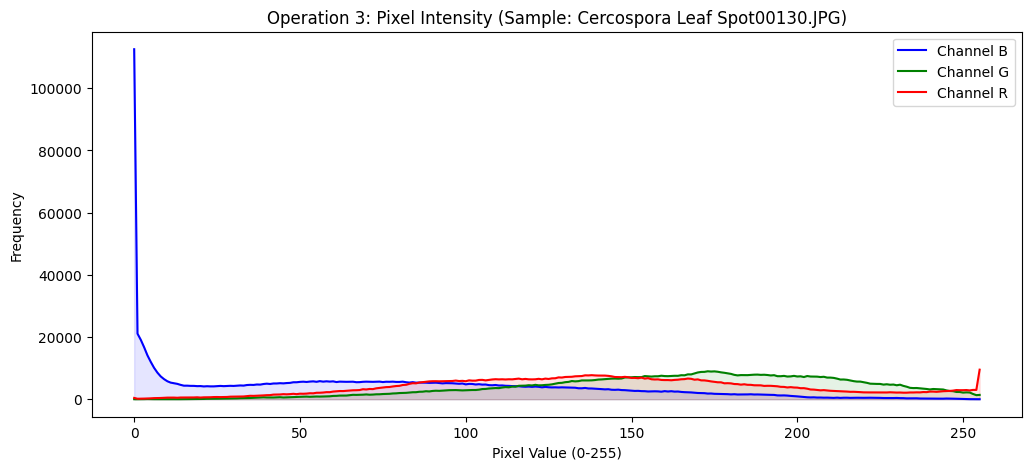

In [29]:
def plot_color_analysis(df, title):
    if df.empty:
        print(f"Skipping color analysis for {title}: DataFrame is empty.")
        return
    # Sample a random image
    sample_path = df['Path'].sample(1).values[0]
    img = cv2.imread(sample_path)

    plt.figure(figsize=(12, 5))
    colors = ('b', 'g', 'r')
    for i, col in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color=col, label=f'Channel {col.upper()}')
        plt.fill_between(range(256), hist.flatten(), color=col, alpha=0.1)

    plt.title(f"Operation 3: Pixel Intensity (Sample: {os.path.basename(sample_path)})")
    plt.xlabel('Pixel Value (0-255)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

plot_color_analysis(df_disease, "Disease Sample Analysis")